# Import Required Modules

In [ ]:
import numpy as np
import pandas as pd
import random
import os
import re
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             precision_score,
                             recall_score,
                             f1_score,
                             log_loss,
                             confusion_matrix)

# Zero Shot

In [ ]:
data = pd.read_excel('News Classification Jais Zero Shot.xlsx')
data.head()

,prompt,Normalized Category,Predicted Category
0,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,ثقافة
1,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,ثقافة
2,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,ثقافة
3,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,ثقافة
4,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,ثقافة


In [ ]:
nor_pre = []
for pr in data['Normalized Category']:
  if "الرياضة" in pr:
    nor_pre.append("Sports")
  elif "الصحة" in pr:
    nor_pre.append("Medical")
  elif "الطب" in pr:
    nor_pre.append("Medical")
  elif "الثقافة" in pr:
    nor_pre.append("Culture")
  elif "المال" in pr:
    nor_pre.append("Finance")
  elif "السياسة" in pr:
    nor_pre.append("Politics")
  elif "الدين" in pr:
    nor_pre.append("Religion")
  elif "التكنولوجيا" in pr:
    nor_pre.append("Tech")
  elif 'خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك' in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف' in pr:
    nor_pre.append("Unclassified")
  elif 'السؤال طويل جدًا. من فضلك اختصر سؤالك.' in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_zero = nor_pre

In [ ]:
true = pd.read_excel('sampled_data.xlsx')
y_true = true['subdirectory'].values
print(classification_report(y_true, pred_zero, digits = 4))

              precision    recall  f1-score   support

     Culture     0.7297    0.3600    0.4821       150
     Finance     0.8529    0.5800    0.6905       150
     Medical     0.9579    0.6067    0.7429       150
       Other     0.0000    0.0000    0.0000         0
    Politics     0.7531    0.4067    0.5281       150
    Religion     0.9487    0.3700    0.5324       100
      Sports     0.9784    0.9067    0.9412       150
        Tech     0.8991    0.6533    0.7568       150
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.5640      1000
   macro avg     0.6800    0.4315    0.5193      1000
weighted avg     0.8705    0.5640    0.6745      1000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode labels
all_labels = sorted(set(y_true) | set(pred_zero))  # ensure consistent order
le = LabelEncoder()
le.fit(all_labels)

y_true_encoded = le.transform(y_true)
pred_zero_encoded = le.transform(pred_zero)

# Step 2: Convert pred_zero to one-hot encoded probabilities
n_classes = len(le.classes_)
y_pred_proba = np.zeros((len(pred_zero_encoded), n_classes))
y_pred_proba[np.arange(len(pred_zero_encoded)), pred_zero_encoded] = 1

# Step 3: Calculate log loss with explicit class labels
loss = log_loss(y_true_encoded, y_pred_proba, labels=np.arange(n_classes))
print("Log Loss:", loss)


Log Loss: 15.715032877655077


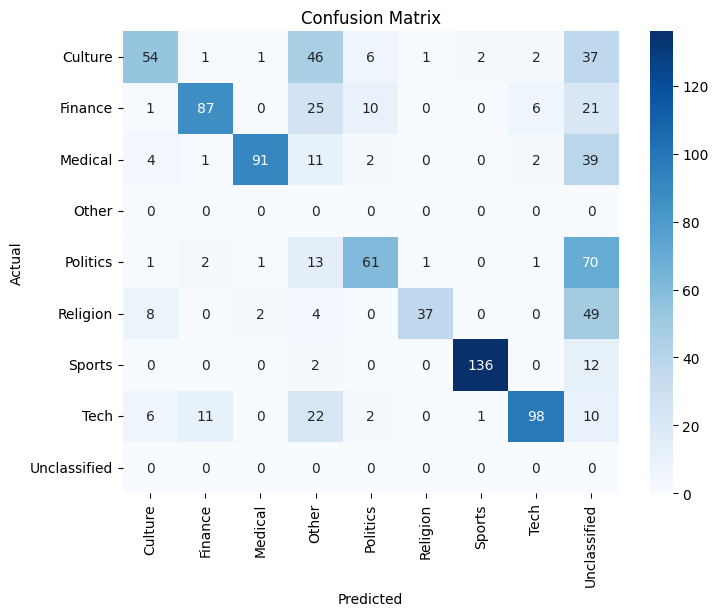

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_zero)
labels = np.unique(pred_zero)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Fewshot

In [ ]:
data2 = pd.read_excel('News Classification Jais Few Shot.xlsx')
data2.head()

,prompt,Predicted,Predicted Normalized
0,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,الثقافة
1,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,الثقافة
2,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,الدين,الدين
3,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,الدين,الدين
4,\nأنت نموذج لغوي مكلف بتصنيف مقالات الصحف العر...,ثقافة,الثقافة


In [ ]:
nor_pre = []
for pr in data2['Predicted Normalized']:
  if "الرياضة" in pr:
    nor_pre.append("Sports")
  elif "الصحة" in pr:
    nor_pre.append("Medical")
  elif "الطب" in pr:
    nor_pre.append("Medical")
  elif "الثقافة" in pr:
    nor_pre.append("Culture")
  elif "المال" in pr:
    nor_pre.append("Finance")
  elif "السياسة" in pr:
    nor_pre.append("Politics")
  elif "الدين" in pr:
    nor_pre.append("Religion")
  elif "التكنولوجيا" in pr:
    nor_pre.append("Tech")
  elif 'خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك' in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف' in pr:
    nor_pre.append("Unclassified")
  elif 'السؤال طويل جدًا. من فضلك اختصر سؤالك.' in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_zero = nor_pre

In [ ]:
true = pd.read_excel('sampled_data.xlsx')
y_true = true['subdirectory'].values
print(classification_report(y_true, pred_zero, digits = 4))

              precision    recall  f1-score   support

     Culture     0.8587    0.5267    0.6529       150
     Finance     0.9383    0.5067    0.6580       150
     Medical     1.0000    0.4533    0.6239       150
       Other     0.0000    0.0000    0.0000         0
    Politics     0.8736    0.5067    0.6414       150
    Religion     0.7692    0.4000    0.5263       100
      Sports     0.9926    0.8933    0.9404       150
        Tech     0.9333    0.8400    0.8842       150
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.5990      1000
   macro avg     0.7073    0.4585    0.5474      1000
weighted avg     0.9164    0.5990    0.7127      1000



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode labels
all_labels = sorted(set(y_true) | set(pred_zero))  # ensure consistent order
le = LabelEncoder()
le.fit(all_labels)

y_true_encoded = le.transform(y_true)
pred_zero_encoded = le.transform(pred_zero)

# Step 2: Convert pred_zero to one-hot encoded probabilities
n_classes = len(le.classes_)
y_pred_proba = np.zeros((len(pred_zero_encoded), n_classes))
y_pred_proba[np.arange(len(pred_zero_encoded)), pred_zero_encoded] = 1

# Step 3: Calculate log loss with explicit class labels
loss = log_loss(y_true_encoded, y_pred_proba, labels=np.arange(n_classes))
print("Log Loss:", loss)

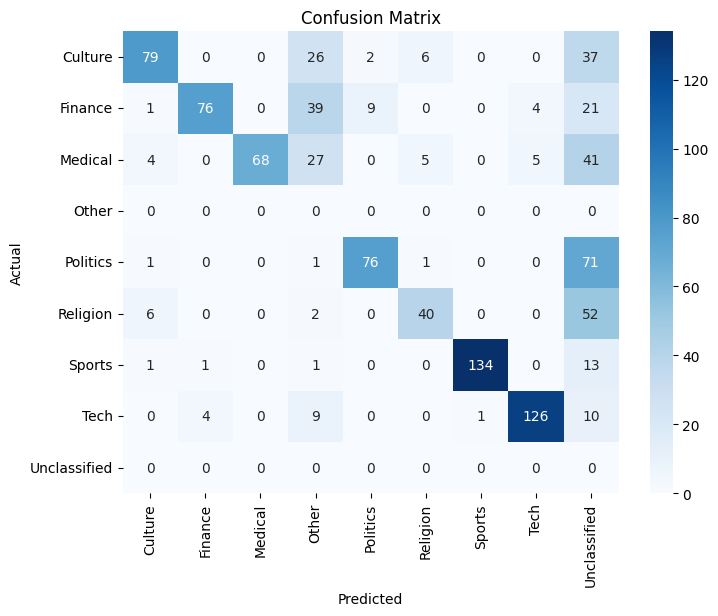

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_zero)
labels = np.unique(pred_zero)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# CoT

In [ ]:
data3 = pd.read_excel('News Classification Jais CoT.xlsx')

In [ ]:
from tqdm import tqdm
max_length = tokenizer.model_max_length
for i in tqdm(range(len(data3[:6]))):
    prompt = data3.iloc[i]["prompt"]
    prompt = prompt[:max_length]
    result = pipe(prompt, pad_token_id=pipe.tokenizer.eos_token_id)
    answer = result[0]['generated_text'].split("الفئة المتوقعة:")[-1].lower()
    print('\n')
    print(result)
    print('\n')
    print(answer)

In [ ]:
pred = []

max_length = tokenizer.model_max_length
for i in tqdm(range(len(data3))):
    prompt = data3.iloc[i]["prompt"]
    # prompt = prompt[:max_length]
    # result = pipe(prompt, pad_token_id=pipe.tokenizer.eos_token_id)
    result = pipe(prompt[:tokenizer.model_max_length], truncation=True, pad_token_id=pipe.tokenizer.eos_token_id)
    answer = result[0]['generated_text'].split("الفئة المتوقعة:")[-1].strip()

    pred.append(answer)

In [ ]:
pred_few = pd.DataFrame()
pred_few['Predicted'] = pred
pred_few['Predicted'].value_counts()

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
df = pd.read_excel('News Classification Jais CoT.xlsx')

In [ ]:
nor_pre = []
for pr in df['Normalized Category']:
  if "الرياضة" in pr:
    nor_pre.append("Sports")
  elif "الصحة" in pr:
    nor_pre.append("Medical")
  elif "الطب" in pr:
    nor_pre.append("Medical")
  elif "الثقافة" in pr:
    nor_pre.append("Culture")
  elif "المال" in pr:
    nor_pre.append("Finance")
  elif "السياسة" in pr:
    nor_pre.append("Politics")
  elif "الدين" in pr:
    nor_pre.append("Religion")
  elif "التكنولوجيا" in pr:
    nor_pre.append("Tech")
  elif 'خطأ: السؤال يحتوي على كلمات محظورة. يرجى مراجعة سؤالك' in pr:
    nor_pre.append("Unclassified")
  elif 'خطأ: الإجابة المولدة تحتوي على كلمات محظورة. يرجى طرح سؤال مختلف' in pr:
    nor_pre.append("Unclassified")
  elif 'السؤال طويل جدًا. من فضلك اختصر سؤالك.' in pr:
    nor_pre.append("Unclassified")
  else:
    nor_pre.append("Other")

In [ ]:
pred_zero = nor_pre

In [ ]:
true = pd.read_excel('sampled_data.xlsx')
y_true = true['subdirectory'].values
print(classification_report(y_true, pred_zero, digits = 4))

              precision    recall  f1-score   support

     Culture     0.8925    0.5533    0.6831       150
     Finance     0.8791    0.5333    0.6639       150
     Medical     1.0000    0.5667    0.7234       150
       Other     0.0000    0.0000    0.0000         0
    Politics     0.7333    0.3667    0.4889       150
    Religion     0.8537    0.3500    0.4965       100
      Sports     0.9779    0.8867    0.9301       150
        Tech     0.8824    0.5000    0.6383       150
Unclassified     0.0000    0.0000    0.0000         0

    accuracy                         0.5460      1000
   macro avg     0.6910    0.4174    0.5138      1000
weighted avg     0.8901    0.5460    0.6688      1000



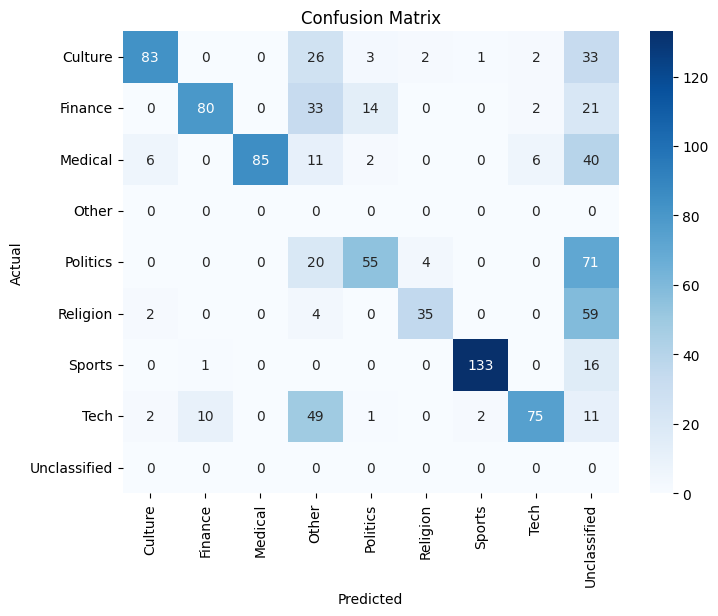

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_true, pred_zero)
labels = np.unique(pred_zero)

# Using seaborn for a more visually appealing matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()